# Analisis Explainability pada Prediksi Permintaan Listrik Menggunakan Skforecast



Tujuan:
1. Mereproduksi implementasi explainability pada model forecasting menggunakan Skforecast.
2. Memahami bentuk data training yang digunakan dalam time series forecasting.
3. Memahami konsep lag dalam forecasting.
4. Menganalisis faktor-faktor yang mempengaruhi hasil prediksi permintaan listrik menggunakan SHAP.

## Explainability pada Forecasting Menggunakan Skforecast

Explainability pada forecasting merupakan pendekatan yang digunakan untuk memahami bagaimana model machine learning menghasilkan prediksi pada data deret waktu (time series). Dalam implementasinya, library Skforecast dapat digunakan untuk membangun model forecasting dengan memanfaatkan algoritma machine learning, seperti LightGBM, sebagai regressor. Model ini memanfaatkan data historis yang diubah ke dalam bentuk supervised learning menggunakan teknik lag, sehingga nilai pada periode sebelumnya dapat digunakan sebagai fitur untuk memprediksi nilai pada periode berikutnya. Selain itu, variabel eksternal seperti temperatur dapat ditambahkan untuk meningkatkan kemampuan prediksi model.

Salah satu metode yang digunakan untuk meningkatkan interpretabilitas model forecasting adalah SHAP (SHapley Additive exPlanations). SHAP memungkinkan identifikasi kontribusi masing-masing fitur terhadap hasil prediksi yang dihasilkan model. Dengan adanya explainability, pengguna tidak hanya memperoleh informasi mengenai nilai prediksi, tetapi juga dapat memahami faktor-faktor yang memengaruhi keputusan model.

Penerapan explainability pada forecasting menjadi aspek yang penting karena dapat meningkatkan transparansi, kemudahan interpretasi, serta kepercayaan terhadap model machine learning. Hal ini sangat bermanfaat dalam mendukung pengambilan keputusan yang didasarkan pada hasil prediksi, terutama ketika model yang digunakan memiliki kompleksitas yang tinggi.


## Informasi Dataset `vic_electricity`

| Aspek                               | Keterangan                                                                                       |
| ----------------------------------- | ------------------------------------------------------------------------------------------------ |
| **Nama Dataset**                    | `vic_electricity`                                                                                |
| **Sumber Dataset**                  | Library Skforecast (`fetch_dataset`)                                                             |
| **Dokumentasi Acuan**               | Skforecast Explainability User Guide versi 0.15.1                                                |
| **Jenis Data**                      | Time Series (Deret Waktu)                                                                        |
| **Domain Data**                     | Energi / Kelistrikan                                                                             |
| **Lokasi Pengamatan**               | Victoria, Australia                                                                              |
| **Tujuan Analisis**                 | Memprediksi permintaan listrik pada periode mendatang                                            |
| **Variabel Target**                 | `Demand`                                                                                         |
| **Variabel Eksogen**                | `Temperature`                                                                                    |
| **Frekuensi Data Awal**             | Data interval waktu tertentu (sesuai dataset asli)                                               |
| **Frekuensi Setelah Preprocessing** | Harian (Daily)                                                                                   |
| **Metode Preprocessing**            | Resampling data menggunakan agregasi harian                                                      |
| **Metode Forecasting**              | Recursive Forecasting menggunakan Skforecast                                                     |
| **Algoritma Regresi**               | LightGBM (`LGBMRegressor`)                                                                       |
| **Jumlah Lag yang Digunakan**       | 7 lag (7 hari sebelumnya)                                                                        |
| **Metode Explainability**           | SHAP (SHapley Additive exPlanations)                                                             |
| **Tujuan Explainability**           | Mengetahui pengaruh masing-masing fitur terhadap hasil prediksi                                  |
| **Output Model**                    | Prediksi permintaan listrik (`Demand`) pada periode berikutnya                                   |
| **Manfaat Hasil Prediksi**          | Membantu perencanaan kapasitas listrik, distribusi energi, dan pengambilan keputusan operasional |


## Deskripsi Variabel Dataset `vic_electricity`

| Variabel         | Tipe Data       | Deskripsi                                                                                                                                                                 |
| ---------------- | --------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `Demand`         | Numerik (Float) | Menunjukkan jumlah permintaan atau konsumsi listrik pada suatu periode waktu tertentu. Variabel ini menjadi target utama yang akan diprediksi oleh model forecasting.     |
| `Temperature`    | Numerik (Float) | Menunjukkan temperatur atau suhu udara pada periode waktu tertentu. Digunakan sebagai variabel eksogen karena suhu dapat memengaruhi tingkat konsumsi listrik masyarakat. |
| `Datetime Index` | Datetime        | Menunjukkan informasi waktu pengamatan data secara kronologis. Digunakan untuk mempertahankan urutan data dalam analisis time series.                                     |


### 1. Install Library
Library yang digunakan:

| Library      | Fungsi                                    |
| ------------ | ----------------------------------------- |
| `skforecast` | Membuat model forecasting time series     |
| `lightgbm`   | Algoritma machine learning yang digunakan |
| `shap`       | Explainability model                      |
| `pandas`     | Pengolahan data                           |
| `matplotlib` | Visualisasi data                          |


In [ ]:
!pip install skforecast==0.15.1
!pip install shap
!pip install lightgbm

### 2. Import Library


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor

from skforecast.recursive import ForecasterRecursive
from skforecast.datasets import fetch_dataset

import shap

### 3. Mengambil Dataset
Dataset vic_electricity merupakan data permintaan listrik di wilayah Victoria, Australia.

Dataset ini memiliki beberapa variabel seperti:

- Demand → jumlah permintaan listrik.
- Temperature → temperatur udara.
- Holiday → indikator hari libur.

In [21]:
data = fetch_dataset(name='vic_electricity')

data.head()

vic_electricity
---------------
Half-hourly electricity demand for Victoria, Australia
O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse
Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,
https://github.com/tidyverts/tsibbledata/.
https://tsibbledata.tidyverts.org/reference/vic_elec.html
Shape of the dataset: (52608, 4)


,Demand,Temperature,Date,Holiday
Time,,,,
2011-12-31 13:00:00,4382.825174,21.40,2012-01-01,True
2011-12-31 13:30:00,4263.365526,21.05,2012-01-01,True
2011-12-31 14:00:00,4048.966046,20.70,2012-01-01,True
2011-12-31 14:30:00,3877.563330,20.55,2012-01-01,True
2011-12-31 15:00:00,4036.229746,20.40,2012-01-01,True


### 4.Melihat Informasi Dataset

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52608 entries, 2011-12-31 13:00:00 to 2014-12-31 12:30:00
Freq: 30min
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Demand       52608 non-null  float64
 1   Temperature  52608 non-null  float64
 2   Date         52608 non-null  object 
 3   Holiday      52608 non-null  bool   
dtypes: bool(1), float64(2), object(1)
memory usage: 1.7+ MB


In [23]:
data.head()

,Demand,Temperature,Date,Holiday
Time,,,,
2011-12-31 13:00:00,4382.825174,21.40,2012-01-01,True
2011-12-31 13:30:00,4263.365526,21.05,2012-01-01,True
2011-12-31 14:00:00,4048.966046,20.70,2012-01-01,True
2011-12-31 14:30:00,3877.563330,20.55,2012-01-01,True
2011-12-31 15:00:00,4036.229746,20.40,2012-01-01,True


Dataset terdiri atas beberapa variabel yang berkaitan dengan konsumsi listrik di Victoria, Australia.

Variabel utama yang akan diprediksi adalah:

- Demand : jumlah permintaan listrik.

Sedangkan Temperature digunakan sebagai variabel tambahan (exogenous variable) yang membantu proses prediksi.

### 5. Visualisasi Data

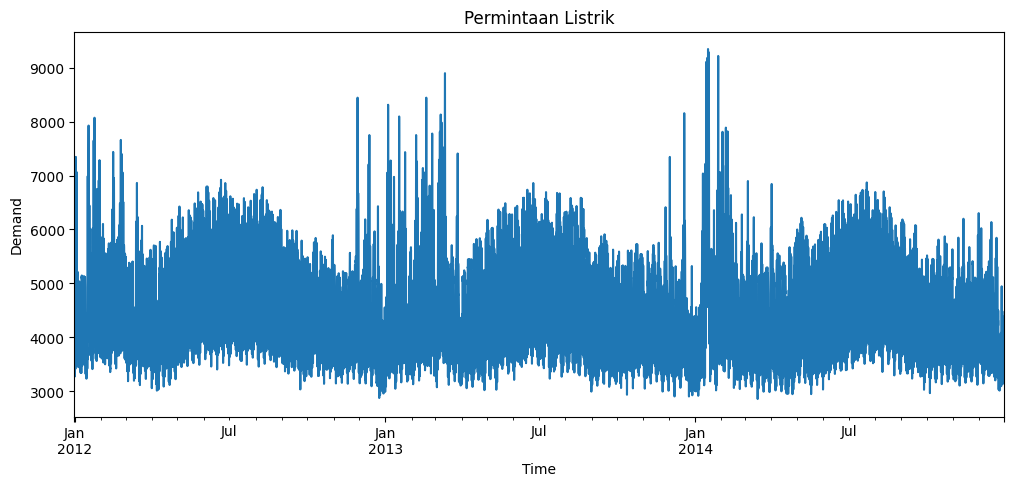

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))

data['Demand'].plot(ax=ax)

plt.title('Permintaan Listrik')
plt.ylabel('Demand')
plt.show()

Visualisasi dilakukan untuk melihat pola permintaan listrik dari waktu ke waktu. Dari grafik dapat diamati adanya fluktuasi serta kemungkinan pola musiman.

### 6. Resampling Data

Pada dokumentasi, data diubah menjadi frekuensi harian.

In [25]:
data = data.resample('D').agg({
    'Demand': 'sum',
    'Temperature': 'mean'
})

data.head()

,Demand,Temperature
Time,,
2011-12-31,82531.745918,21.047727
2012-01-01,227778.257304,26.578125
2012-01-02,275490.988882,31.751042
2012-01-03,258955.329422,24.567708
2012-01-04,213792.376946,18.191667


Proses resampling dilakukan untuk mengubah data menjadi data harian.

- Demand dijumlahkan setiap hari.
- Temperature dirata-ratakan setiap hari.

Tujuannya agar model lebih mudah mempelajari pola permintaan listrik harian.

### 7. Membagi Data Training dan Testing

In [26]:
steps = 7

data_train = data[:-steps]
data_test = data[-steps:]

melihat ukuran:

In [27]:
print("Training:", data_train.shape)
print("Testing :", data_test.shape)

Training: (1090, 2)
Testing : (7, 2)


Data dibagi menjadi dua bagian:

- Data training digunakan untuk melatih model.
- Data testing digunakan untuk mengevaluasi kemampuan model dalam memprediksi data yang belum pernah dilihat sebelumnya.

### 8. Memisahkan Variabel Target dan Variabel Eksogen

In [28]:
y_train = data_train['Demand']
exog_train = data_train[['Temperature']]

y_test = data_test['Demand']
exog_test = data_test[['Temperature']]

Variabel target (y) adalah Demand yang merepresentasikan jumlah permintaan listrik.

Variabel eksogen (exog) adalah Temperature yang digunakan sebagai informasi tambahan dalam proses forecasting.

### 9. Membuat Model Forecasting

In [29]:
forecaster = ForecasterRecursive(
    regressor=LGBMRegressor(
        random_state=123,
        verbose=-1
    ),
    lags=7
)

Model menggunakan algoritma LightGBM.

Parameter lags=7 menunjukkan bahwa model menggunakan data permintaan listrik 7 hari sebelumnya untuk memprediksi permintaan listrik pada hari berikutnya.

### 10. Melatih Model

In [30]:
forecaster.fit(
    y=y_train,
    exog=exog_train
)

Tahap fitting bertujuan agar model dapat mempelajari hubungan antara permintaan listrik sebelumnya, temperatur, dan permintaan listrik yang akan datang.

### 11. Melakukan Prediksi

In [31]:
predictions = forecaster.predict(
    steps=steps,
    exog=exog_test
)

predictions

,pred
2014-12-25,196058.886665
2014-12-26,202043.904953
2014-12-27,200527.743695
2014-12-28,226175.933678
2014-12-29,220784.966138
2014-12-30,212101.290487
2014-12-31,192403.998441


Model menghasilkan prediksi permintaan listrik untuk periode testing menggunakan informasi historis dan temperatur.

### 12. Visualisasi Hasil Prediksi

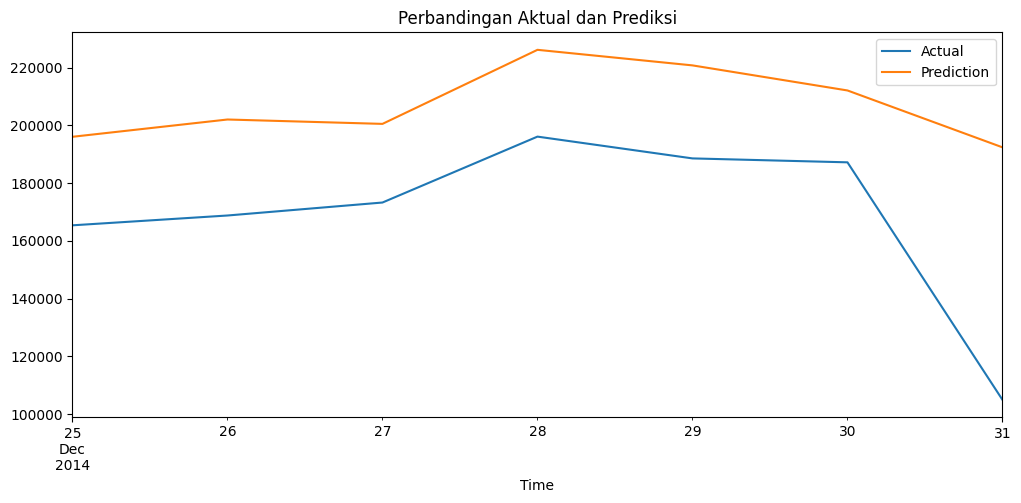

In [32]:
fig, ax = plt.subplots(figsize=(12,5))

y_test.plot(ax=ax, label='Actual')
predictions.plot(ax=ax, label='Prediction')

plt.legend()
plt.title('Perbandingan Aktual dan Prediksi')
plt.show()

Grafik digunakan untuk membandingkan hasil prediksi model dengan nilai aktual pada data testing.

### 13. Membuat Data Training untuk Explainability

In [33]:
X_train, y_train = forecaster.create_train_X_y(
    y=y_train,
    exog=exog_train
)

X_train.head()

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
Time,,,,,,,,
2012-01-07,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,82531.745918,24.098958
2012-01-08,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,20.223958
2012-01-09,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,19.161458
2012-01-10,216201.836844,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,16.042708
2012-01-11,217176.907910,216201.836844,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,14.815625


Data training diubah ke dalam bentuk supervised learning sehingga dapat digunakan untuk analisis explainability menggunakan SHAP.

### 14. Explainability Menggunakan SHAP

In [34]:
explainer = shap.TreeExplainer(
    forecaster.regressor
)

shap_values = explainer.shap_values(X_train)

### 15. Menampilkan SHAP Summary Plot

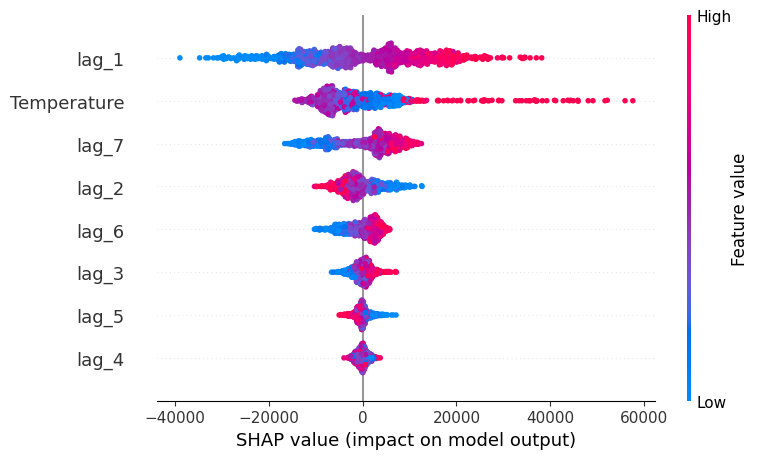

In [35]:
shap.summary_plot(
    shap_values,
    X_train
)

SHAP digunakan untuk mengetahui kontribusi masing-masing fitur terhadap hasil prediksi.

Semakin besar nilai SHAP suatu fitur, semakin besar pengaruh fitur tersebut terhadap prediksi permintaan listrik.

## Kesimpulan Konsep Penting

| Konsep                      | Penjelasan                                                                                            |
| --------------------------- | ----------------------------------------------------------------------------------------------------- |
| **Time Series Forecasting** | Teknik memprediksi nilai masa depan berdasarkan data historis yang berurutan menurut waktu.           |
| **Lag**                     | Nilai pada periode sebelumnya yang digunakan sebagai fitur prediksi.                                  |
| **Supervised Learning**     | Pendekatan pembelajaran mesin yang menggunakan input (X) dan output (y) untuk melatih model.          |
| **LightGBM**                | Algoritma machine learning berbasis gradient boosting yang digunakan untuk forecasting.               |
| **Exogenous Variable**      | Variabel tambahan dari luar target utama yang dapat mempengaruhi prediksi, seperti temperatur.        |
| **SHAP**                    | Metode explainability untuk menjelaskan kontribusi masing-masing fitur terhadap hasil prediksi model. |
| **Explainability**          | Kemampuan untuk memahami dan menjelaskan alasan model menghasilkan suatu prediksi tertentu.           |


## Menjawab Pertanyaan

##### 1. Analisa prediksi tentang apa?

Analisis prediksi yang dilakukan pada praktikum ini bertujuan untuk memprediksi permintaan listrik (electricity demand) di wilayah Victoria, Australia menggunakan data historis permintaan listrik sebelumnya serta informasi temperatur sebagai variabel tambahan (exogenous variable).

Variabel yang diprediksi adalah Demand, yaitu jumlah permintaan atau konsumsi listrik pada periode waktu tertentu. Prediksi dilakukan menggunakan model forecasting berbasis machine learning dengan algoritma LightGBM yang diimplementasikan melalui library Skforecast.

Tujuan dari prediksi ini adalah untuk mengetahui perkiraan kebutuhan listrik pada periode mendatang sehingga dapat membantu penyedia layanan listrik dalam melakukan perencanaan kapasitas pembangkit, pengelolaan distribusi energi, serta pengambilan keputusan operasional secara lebih efektif dan efisien.

Selain melakukan prediksi, pada praktikum ini juga dilakukan analisis explainability untuk memahami faktor-faktor yang mempengaruhi hasil prediksi model menggunakan metode seperti Feature Importance, Permutation Importance, SHAP Values, dan Partial Dependence Plot (PDP).

##### 2. Bagaimana bentuk data trainingnya (apa saja inputnya dan apa outputnya)?

Pada kasus forecasting permintaan listrik ini, data training awalnya berbentuk data time series, yaitu data yang tersusun berdasarkan urutan waktu. Namun, agar dapat digunakan oleh algoritma machine learning seperti LightGBM, data tersebut perlu diubah menjadi bentuk supervised learning.

Bentuk data training yang terbentuk adalah berupa matriks fitur (X) dan target (y). Proses pembentukan data training dilakukan dengan menggunakan metode lag, yaitu mengambil beberapa nilai pada periode sebelumnya sebagai fitur untuk memprediksi nilai pada periode berikutnya.

Pada ini digunakan 7 lag, sehingga model menggunakan data permintaan listrik selama 7 hari sebelumnya untuk memprediksi permintaan listrik pada hari berikutnya. Selain itu, digunakan juga variabel Temperature sebagai variabel eksogen (variabel tambahan) yang dapat mempengaruhi permintaan listrik.

**Input ($X$)**

Input yang digunakan dalam model terdiri dari:

* `lag_1` = Demand pada 1 hari sebelumnya
* `lag_2` = Demand pada 2 hari sebelumnya
* `lag_3` = Demand pada 3 hari sebelumnya
* `lag_4` = Demand pada 4 hari sebelumnya
* `lag_5` = Demand pada 5 hari sebelumnya
* `lag_6` = Demand pada 6 hari sebelumnya
* `lag_7` = Demand pada 7 hari sebelumnya
* `Temperature` = Temperatur pada periode yang diprediksi

Sehingga bentuk input dapat dituliskan sebagai berikut:

| lag_7       | lag_6       | lag_5       | lag_4       | lag_3       | lag_2       | lag_1       | Temperature    |
| ----------- | ----------- | ----------- | ----------- | ----------- | ----------- | ----------- | -------------- |
| Demand(t−7) | Demand(t−6) | Demand(t−5) | Demand(t−4) | Demand(t−3) | Demand(t−2) | Demand(t−1) | Temperature(t) |

**Output ($y$)**

Output yang diprediksi oleh model adalah:

* `Demand(t)` = permintaan listrik pada periode (hari) yang akan diprediksi.

Bentuk output:

| Output    |
| --------- |
| Demand(t) |

Dengan demikian, model mempelajari hubungan antara permintaan listrik pada 7 hari sebelumnya serta temperatur, untuk memprediksi permintaan listrik pada hari berikutnya.

**Kesimpulan**

Bentuk data training pada kasus ini adalah data supervised learning, di mana input (X) terdiri dari fitur lag (lag_1 hingga lag_7) dan variabel temperatur (Temperature), sedangkan output (y) adalah nilai permintaan listrik (Demand) yang akan diprediksi. Proses ini memungkinkan model machine learning untuk mempelajari pola historis permintaan listrik dan menghasilkan prediksi untuk periode selanjutnya.

##### 3. Apa itu lag?

Lag merupakan nilai observasi pada periode sebelumnya yang digunakan sebagai fitur atau variabel input dalam proses forecasting time series. Lag memungkinkan model untuk memanfaatkan informasi historis dalam memprediksi nilai di masa depan.

Pada ini digunakan 7 lag, yang berarti model menggunakan data permintaan listrik dari 7 hari sebelumnya untuk memprediksi permintaan listrik pada hari berikutnya.

Sebagai contoh:
| Hari             | Demand |
| ---------------- | ------ |
| Senin            | 1200   |
| Selasa           | 1250   |
| Rabu             | 1230   |
| Kamis            | 1300   |
| Jumat            | 1280   |
| Sabtu            | 1320   |
| Minggu           | 1350   |
| Senin berikutnya | ?      |

Untuk memprediksi permintaan listrik pada Senin berikutnya, model menggunakan:

- Lag 1 = Demand hari Minggu (1350)
- Lag 2 = Demand hari Sabtu (1320)
- Lag 3 = Demand hari Jumat (1280)
- Lag 4 = Demand hari Kamis (1300)
- Lag 5 = Demand hari Rabu (1230)
- Lag 6 = Demand hari Selasa (1250)
- Lag 7 = Demand hari Senin (1200)

Penggunaan lag sangat penting dalam forecasting karena data time series memiliki keterkaitan antar waktu, sehingga pola masa lalu dapat membantu memprediksi nilai di masa depan.

##### 4. Jelaskan proses analisis yang dilakukan dari kasus di atas.

Proses analisis yang dilakukan pada praktikum ini terdiri dari beberapa tahapan sebagai berikut:

- 1. Menginstal dan Mengimpor Library

Tahap pertama adalah menginstal dan mengimpor library yang dibutuhkan, yaitu **Skforecast**, **LightGBM**, **SHAP**, **Pandas**, **NumPy**, dan **Matplotlib**. Library tersebut digunakan untuk membangun model forecasting, melakukan pengolahan data, visualisasi, serta analisis explainability.

- 2. Memuat Dataset `vic_electricity`

Dataset `vic_electricity` diambil menggunakan fungsi `fetch_dataset()` dari library Skforecast. Dataset ini berisi data permintaan listrik di Victoria, Australia, serta informasi temperatur yang digunakan sebagai variabel tambahan dalam proses prediksi.

- 3. Eksplorasi dan Visualisasi Data

Dilakukan eksplorasi data dengan melihat informasi dataset menggunakan `data.info()` dan `data.head()` untuk mengetahui struktur data, tipe data, dan variabel yang tersedia. Selanjutnya dilakukan visualisasi terhadap variabel `Demand` untuk mengamati pola permintaan listrik dari waktu ke waktu.

- 4. Preprocessing Data

Data kemudian diubah menjadi frekuensi harian (daily) melalui proses **resampling**. Pada tahap ini:

* Variabel `Demand` dijumlahkan setiap hari.
* Variabel `Temperature` dihitung rata-ratanya setiap hari.

Tujuan dari proses ini adalah agar model lebih mudah dalam mempelajari pola permintaan listrik harian.

- 5. Pembagian Data Training dan Testing

Dataset dibagi menjadi dua bagian, yaitu:

**Data training**, yang digunakan untuk melatih model forecasting.

**Data testing**, yang digunakan untuk mengevaluasi kemampuan model dalam melakukan prediksi terhadap data yang belum pernah digunakan selama proses pelatihan.

- 6. Menentukan Variabel Target dan Variabel Eksogen

Variabel target yang digunakan adalah **Demand**, yaitu permintaan listrik yang akan diprediksi. Sedangkan variabel

**Temperature** digunakan sebagai variabel eksogen (exogenous variable) yang membantu meningkatkan kemampuan prediksi model.

- 7. Pembuatan Model Forecasting

Model forecasting dibuat menggunakan **ForecasterRecursive** dengan algoritma **LightGBM Regressor**. Model menggunakan **7 lag**, yang berarti model memanfaatkan data permintaan listrik selama 7 hari sebelumnya untuk memprediksi permintaan listrik pada hari berikutnya.

- 8. Pelatihan Model

Model kemudian dilatih menggunakan data training melalui proses `fit()`. Pada tahap ini, model mempelajari hubungan antara permintaan listrik pada periode sebelumnya, temperatur, dan permintaan listrik yang akan datang.

- 9. Melakukan Prediksi

Setelah model selesai dilatih, dilakukan proses prediksi terhadap data testing menggunakan fungsi `predict()`. Hasil prediksi kemudian dibandingkan dengan data aktual untuk melihat kemampuan model dalam melakukan forecasting.

- 10. Visualisasi Hasil Prediksi

Dilakukan visualisasi antara hasil prediksi dan data aktual untuk mengetahui sejauh mana model mampu mengikuti pola permintaan listrik yang sebenarnya.

- 11. Analisis Explainability Menggunakan SHAP

Untuk memahami bagaimana model menghasilkan prediksi, dilakukan analisis explainability menggunakan **SHAP (SHapley Additive exPlanations)**. Proses ini diawali dengan mengubah data training menjadi bentuk supervised learning menggunakan fungsi `create_train_X_y()`, kemudian menghitung nilai SHAP menggunakan `TreeExplainer`.

Selanjutnya, **SHAP Summary Plot** digunakan untuk menunjukkan kontribusi masing-masing fitur terhadap hasil prediksi. Fitur dengan nilai SHAP yang lebih besar menunjukkan bahwa fitur tersebut memiliki pengaruh yang lebih besar terhadap prediksi permintaan listrik.

- 12. Interpretasi Hasil

Berdasarkan hasil SHAP Summary Plot, dapat diketahui fitur-fitur yang paling mempengaruhi prediksi permintaan listrik. Analisis ini membantu meningkatkan transparansi model sehingga hasil prediksi menjadi lebih mudah dipahami dan diinterpretasikan.
